# Task 12: High-Dimensional Latent Space Anomaly Detection via Convolutional Autoencoders

**Objective:** Identify micro-structural defects/outliers by training a Convolutional Autoencoder exclusively on fault-free images, using a custom pixel-wise Structural Similarity Index (SSIM) loss, then mapping reconstruction error to localize anomalies at inference time.

**Tech stack:** PyTorch, SciPy (Gaussian filtering for SSIM), Scikit-Learn (threshold selection / ROC), Matplotlib.


In [1]:

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

torch.manual_seed(0)
np.random.seed(0)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device


device(type='cpu')

## 1. Synthetic manufacturing dataset

'Fault-free' images are clean, regular textured grids (representing a normal manufactured surface). 'Defective' images contain the same background texture plus a randomly placed scratch/blob anomaly. The model is trained **only** on fault-free samples, as required in an unsupervised anomaly-detection setting.

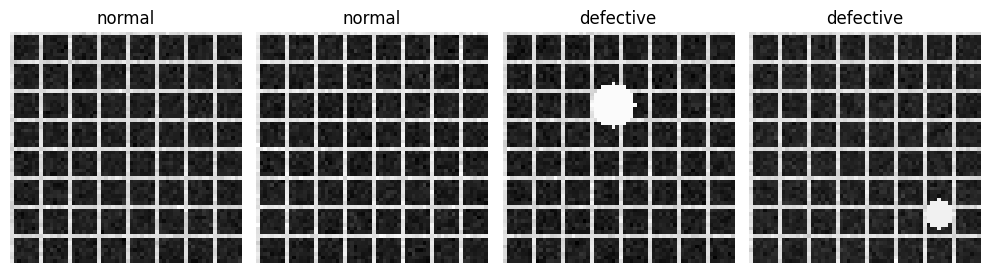

In [2]:

IMG_SIZE = 64

def make_texture(img_size=IMG_SIZE):
    # regular grid texture + mild noise, standing in for a normal manufactured surface
    base = np.zeros((img_size, img_size), dtype=np.float32)
    step = 8
    base[::step, :] = 0.6
    base[:, ::step] = 0.6
    base += np.random.randn(img_size, img_size).astype(np.float32) * 0.03
    return np.clip(base + 0.2, 0, 1)

def add_defect(img):
    img = img.copy()
    s = img.shape[0]
    cy, cx = np.random.randint(10, s-10, size=2)
    r = np.random.randint(3, 7)
    yy, xx = np.meshgrid(np.arange(s), np.arange(s), indexing='ij')
    mask = (yy-cy)**2 + (xx-cx)**2 <= r**2
    img[mask] = np.random.uniform(0.85, 1.0)
    return img, mask.astype(np.float32)

def make_normal_batch(n):
    return torch.from_numpy(np.stack([make_texture() for _ in range(n)])).unsqueeze(1).float()

def make_defect_batch(n):
    imgs, masks = [], []
    for _ in range(n):
        clean = make_texture()
        defective, mask = add_defect(clean)
        imgs.append(defective); masks.append(mask)
    return (torch.from_numpy(np.stack(imgs)).unsqueeze(1).float(),
            torch.from_numpy(np.stack(masks)).unsqueeze(1).float())

fig, axes = plt.subplots(1, 4, figsize=(10, 3))
normal_ex = make_normal_batch(2)
defect_ex, defect_masks = make_defect_batch(2)
axes[0].imshow(normal_ex[0,0], cmap='gray'); axes[0].set_title('normal'); axes[0].axis('off')
axes[1].imshow(normal_ex[1,0], cmap='gray'); axes[1].set_title('normal'); axes[1].axis('off')
axes[2].imshow(defect_ex[0,0], cmap='gray'); axes[2].set_title('defective'); axes[2].axis('off')
axes[3].imshow(defect_ex[1,0], cmap='gray'); axes[3].set_title('defective'); axes[3].axis('off')
plt.tight_layout(); plt.show()


## 2. Convolutional Autoencoder with a dense structural bottleneck

In [3]:

class ConvAutoencoder(nn.Module):
    def __init__(self, latent_dim=32, img_size=IMG_SIZE):
        super().__init__()
        self.img_size = img_size
        self.encoder_conv = nn.Sequential(
            nn.Conv2d(1, 16, 3, stride=2, padding=1), nn.BatchNorm2d(16), nn.ReLU(True),   # 64->32
            nn.Conv2d(16, 32, 3, stride=2, padding=1), nn.BatchNorm2d(32), nn.ReLU(True),  # 32->16
            nn.Conv2d(32, 64, 3, stride=2, padding=1), nn.BatchNorm2d(64), nn.ReLU(True),  # 16->8
        )
        self.flat_dim = 64 * (img_size // 8) * (img_size // 8)
        self.fc_enc = nn.Linear(self.flat_dim, latent_dim)   # dense structural bottleneck
        self.fc_dec = nn.Linear(latent_dim, self.flat_dim)
        self.decoder_conv = nn.Sequential(
            nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1), nn.BatchNorm2d(32), nn.ReLU(True),  # 8->16
            nn.ConvTranspose2d(32, 16, 4, stride=2, padding=1), nn.BatchNorm2d(16), nn.ReLU(True),  # 16->32
            nn.ConvTranspose2d(16, 1, 4, stride=2, padding=1), nn.Sigmoid(),                          # 32->64
        )
        self.spatial = img_size // 8

    def forward(self, x):
        h = self.encoder_conv(x)
        h_flat = h.view(h.size(0), -1)
        z = self.fc_enc(h_flat)                       # bottleneck latent vector
        h_dec = self.fc_dec(z).view(-1, 64, self.spatial, self.spatial)
        out = self.decoder_conv(h_dec)
        return out, z

model = ConvAutoencoder().to(device)
sum(p.numel() for p in model.parameters())


331153

## 3. Custom pixel-wise SSIM loss

SSIM compares local luminance, contrast, and structure using Gaussian-weighted local statistics. We implement it with a depthwise Gaussian-blur convolution so it is fully differentiable and runs on GPU.

In [4]:

def gaussian_kernel(window_size=11, sigma=1.5):
    coords = torch.arange(window_size).float() - window_size // 2
    g = torch.exp(-(coords ** 2) / (2 * sigma ** 2))
    g = g / g.sum()
    kernel_2d = g[:, None] @ g[None, :]
    return kernel_2d

class SSIMLoss(nn.Module):
    def __init__(self, window_size=11, sigma=1.5, C1=0.01**2, C2=0.03**2):
        super().__init__()
        kernel = gaussian_kernel(window_size, sigma).unsqueeze(0).unsqueeze(0)
        self.register_buffer('kernel', kernel)
        self.window_size = window_size
        self.C1, self.C2 = C1, C2

    def _filter(self, x):
        pad = self.window_size // 2
        return F.conv2d(x, self.kernel, padding=pad)

    def ssim_map(self, x, y):
        mu_x = self._filter(x)
        mu_y = self._filter(y)
        mu_x2, mu_y2, mu_xy = mu_x * mu_x, mu_y * mu_y, mu_x * mu_y

        sigma_x2 = self._filter(x * x) - mu_x2
        sigma_y2 = self._filter(y * y) - mu_y2
        sigma_xy = self._filter(x * y) - mu_xy

        numerator = (2 * mu_xy + self.C1) * (2 * sigma_xy + self.C2)
        denominator = (mu_x2 + mu_y2 + self.C1) * (sigma_x2 + sigma_y2 + self.C2)
        return numerator / denominator  # per-pixel SSIM, range ~[-1,1]

    def forward(self, x, y):
        ssim_map = self.ssim_map(x, y)
        return 1 - ssim_map.mean()  # loss: 0 when identical

ssim_loss_fn = SSIMLoss().to(device)


## 4. Training on fault-free images only

epoch 5/25 loss=0.4682


epoch 10/25 loss=0.3171


epoch 15/25 loss=0.2134


epoch 20/25 loss=0.1376


epoch 25/25 loss=0.0925


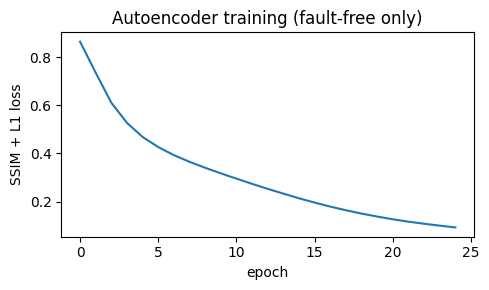

In [5]:

opt = torch.optim.Adam(model.parameters(), lr=1e-3)
epochs = 25
batch_size = 32
history = []

for epoch in range(epochs):
    model.train()
    imgs = make_normal_batch(batch_size).to(device)
    recon, z = model(imgs)
    loss = ssim_loss_fn(recon, imgs) + 0.1 * F.l1_loss(recon, imgs)  # SSIM + small L1 for pixel fidelity
    opt.zero_grad(); loss.backward(); opt.step()
    history.append(loss.item())
    if (epoch + 1) % 5 == 0:
        print(f"epoch {epoch+1}/{epochs} loss={loss.item():.4f}")

plt.figure(figsize=(5,3))
plt.plot(history)
plt.xlabel('epoch'); plt.ylabel('SSIM + L1 loss'); plt.title('Autoencoder training (fault-free only)')
plt.tight_layout(); plt.show()


## 5. Inference: reconstruction-error anomaly maps

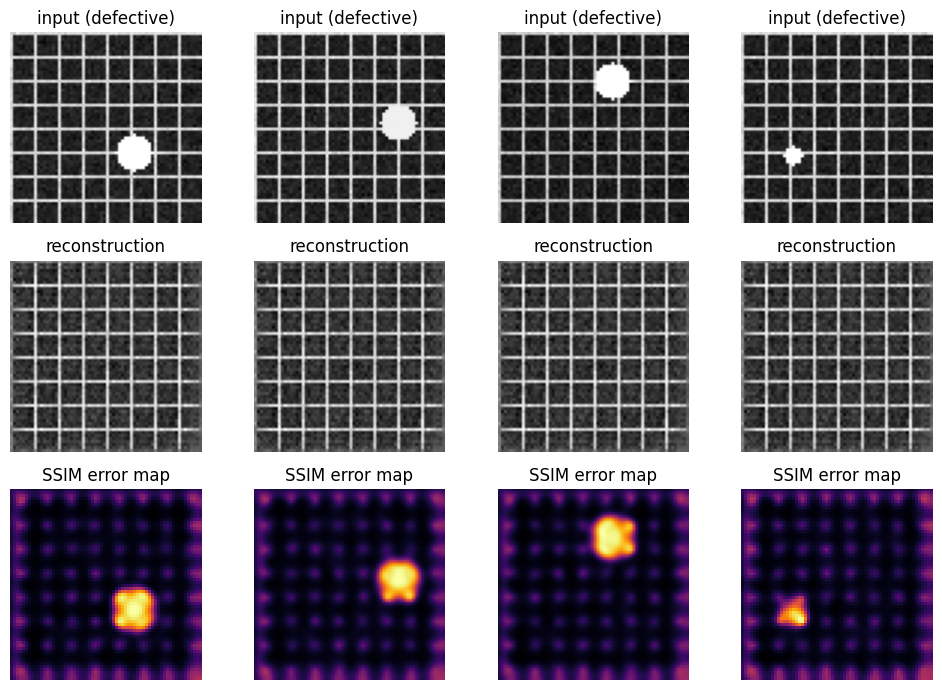

In [6]:

model.eval()
test_normal = make_normal_batch(4).to(device)
test_defect, test_masks = make_defect_batch(4)
test_defect = test_defect.to(device)

with torch.no_grad():
    recon_normal, _ = model(test_normal)
    recon_defect, _ = model(test_defect)

def pixelwise_ssim_error(x, recon):
    ssim_map = ssim_loss_fn.ssim_map(x, recon)
    return (1 - ssim_map).clamp(min=0)  # higher = more anomalous

err_normal = pixelwise_ssim_error(test_normal, recon_normal).cpu()
err_defect = pixelwise_ssim_error(test_defect, recon_defect).cpu()

fig, axes = plt.subplots(3, 4, figsize=(10, 7))
for i in range(4):
    axes[0, i].imshow(test_defect[i,0].cpu(), cmap='gray'); axes[0,i].set_title('input (defective)'); axes[0,i].axis('off')
    axes[1, i].imshow(recon_defect[i,0].cpu(), cmap='gray'); axes[1,i].set_title('reconstruction'); axes[1,i].axis('off')
    axes[2, i].imshow(err_defect[i,0], cmap='inferno'); axes[2,i].set_title('SSIM error map'); axes[2,i].axis('off')
plt.tight_layout(); plt.show()


## 6. Quantitative evaluation: image-level anomaly scoring (ROC/AUC)

We use the mean per-image reconstruction error as an anomaly score and evaluate separability between normal and defective images with an ROC curve, a standard way to report anomaly-detection quality independent of a fixed threshold.

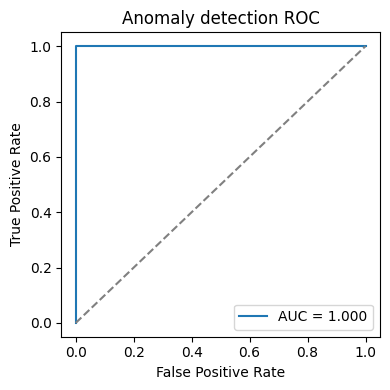

Mean SSIM-error score -- normal: 0.1256  defective: 0.1430


In [7]:

n_eval = 100
normal_eval = make_normal_batch(n_eval).to(device)
defect_eval, _ = make_defect_batch(n_eval)
defect_eval = defect_eval.to(device)

with torch.no_grad():
    recon_n, _ = model(normal_eval)
    recon_d, _ = model(defect_eval)

score_normal = pixelwise_ssim_error(normal_eval, recon_n).mean(dim=[1,2,3]).cpu().numpy()
score_defect = pixelwise_ssim_error(defect_eval, recon_d).mean(dim=[1,2,3]).cpu().numpy()

scores = np.concatenate([score_normal, score_defect])
y_true = np.concatenate([np.zeros(n_eval), np.ones(n_eval)])

fpr, tpr, thresholds = roc_curve(y_true, scores)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(4,4))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('Anomaly detection ROC'); plt.legend()
plt.tight_layout(); plt.show()

print(f"Mean SSIM-error score -- normal: {score_normal.mean():.4f}  defective: {score_defect.mean():.4f}")


## Conclusion

Because the autoencoder is trained exclusively on fault-free textures, its dense bottleneck learns a compressed representation of *normal* structure only; defective regions cannot be reconstructed faithfully and therefore produce locally high SSIM error, which both localizes the anomaly spatially (error map) and separates normal from defective images at the image level (ROC/AUC).